# Scoring base de compatibilidad — Licitaciones vs. Los Tilos

Notebook para construir un **scoring base propio** usando:

- `fichas_licitaciones_muestra_10_unificado_v11_desde_tilos_limpio.parquet`
- `00_Indice_Licitaciones.xlsx`

El objetivo es medir compatibilidad entre cada licitación de la muestra y el histórico/índice de licitaciones asociadas a Los Tilos.

Este scoring es una primera versión objetiva y auditable. No usa IA externa. Se basa en variables estructuradas y similitud textual.

## 0. Criterio metodológico

La lógica del scoring es comparar cada licitación nueva contra las licitaciones del índice de Los Tilos.

Dimensiones propuestas:

| Dimensión | Peso base | Qué mide |
|---|---:|---|
| CPV / actividad | 30 % | Coincidencia exacta o parcial con CPV históricos |
| Similitud textual | 25 % | Parecido entre título/objeto/descripción y licitaciones previas |
| Importe | 15 % | Si el presupuesto cae dentro de rangos comparables al histórico |
| Tipo/procedimiento | 10 % | Si el tipo o procedimiento ya aparece en el índice |
| Región/ubicación | 10 % | Si la zona territorial coincide con experiencia previa |
| Órgano contratante | 10 % | Si el órgano contratante ya aparece en el índice |

Si alguna dimensión no tiene columnas disponibles, no se inventa el dato: esa dimensión queda en `NaN` y los pesos se renormalizan entre las dimensiones calculables.

In [1]:
# ===============================
# 1. Librerías
# ===============================

from pathlib import Path
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 150)

In [4]:
from pathlib import Path

# El notebook está dentro de la carpeta Notebooks.
# Por eso usamos ".." para subir a la raíz del proyecto.
BASE_DIR = Path("..").resolve()

PATH_MUESTRA = (
    BASE_DIR
    / "data"
    / "Silver"
    / "fichas_licitaciones_muestra_10_unificado_v11_desde_tilos_limpio.parquet"
)

PATH_INDICE_TILOS = (BASE_DIR  
    / "data"
    / "Silver"
    /"00_Indice_Licitaciones.xlsx"
)
print("Base del proyecto:", BASE_DIR)
print("Ruta muestra parquet:", PATH_MUESTRA)
print("Existe muestra:", PATH_MUESTRA.exists())
print("Ruta índice Excel:", PATH_INDICE_TILOS)
print("Existe índice:", PATH_INDICE_TILOS.exists())

Base del proyecto: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado
Ruta muestra parquet: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\fichas_licitaciones_muestra_10_unificado_v11_desde_tilos_limpio.parquet
Existe muestra: True
Ruta índice Excel: C:\Users\Usuario\TFM\TFM_scraping_contratacion_estado\data\Silver\00_Indice_Licitaciones.xlsx
Existe índice: True


In [5]:
# ===============================
# 3. Carga de datos
# ===============================

if not PATH_MUESTRA.exists():
    raise FileNotFoundError(f"No existe el archivo parquet: {PATH_MUESTRA.resolve()}")

if not PATH_INDICE_TILOS.exists():
    raise FileNotFoundError(f"No existe el archivo Excel: {PATH_INDICE_TILOS.resolve()}")

df_muestra_raw = pd.read_parquet(PATH_MUESTRA)
df_tilos_raw = pd.read_excel(PATH_INDICE_TILOS)

print("Shape muestra:", df_muestra_raw.shape)
print("Shape índice Tilos:", df_tilos_raw.shape)

print("Columnas muestra:")
print(df_muestra_raw.columns.tolist())

print("Columnas índice Tilos:")
print(df_tilos_raw.columns.tolist())

Shape muestra: (10, 82)
Shape índice Tilos: (25, 15)
Columnas muestra:
['licitacion_id', 'titulo', 'detail_url', 'updated', 'expediente', 'tipo_contrato_codigo', 'lugar_ejecucion_codigo', 'cpv_codes', 'organo_contratacion', 'estado_codigo', 'fecha_publicacion', 'procedimiento_codigo', 'importe_sin_impuestos', 'fuente_publicacion', 'presentacion_hasta', 'presentacion_hora', 'notice_types', 'organo_dir3', 'contrato_duracion', 'contrato_duracion_unidad', 'ofertas_recibidas', 'adjudicatario', 'adjudicatario_nif', 'estado', 'tipo_contrato', 'url', 'cpv_descripcion', 'cpv_nivel', 'portal', 'tipo_fuente', 'tipo_anuncio', 'titulo_original', 'titulo_web', 'numero_expediente_web', 'fecha_publicacion_texto', 'hora_publicacion', 'entidad_adjudicadora_web', 'organo_contratacion_web', 'objeto_contrato_web', 'objeto_web', 'descripcion_general', 'tipo_contrato_web', 'tipo_procedimiento_web', 'procedimiento_adjudicacion_web', 'tipo_tramitacion_web', 'sistema_contratacion_web', 'metodo_presentacion_ofer

In [6]:
# Revisión rápida de las primeras filas

print("Muestra de licitaciones:")
display(df_muestra_raw.head(3))

print("Índice Tilos:")
display(df_tilos_raw.head(3))

Muestra de licitaciones:


,licitacion_id,titulo,detail_url,updated,expediente,tipo_contrato_codigo,lugar_ejecucion_codigo,cpv_codes,organo_contratacion,estado_codigo,fecha_publicacion,procedimiento_codigo,importe_sin_impuestos,fuente_publicacion,presentacion_hasta,presentacion_hora,notice_types,organo_dir3,contrato_duracion,contrato_duracion_unidad,ofertas_recibidas,adjudicatario,adjudicatario_nif,estado,tipo_contrato,url,cpv_descripcion,cpv_nivel,portal,tipo_fuente,tipo_anuncio,titulo_original,titulo_web,numero_expediente_web,fecha_publicacion_texto,hora_publicacion,entidad_adjudicadora_web,organo_contratacion_web,objeto_contrato_web,objeto_web,descripcion_general,tipo_contrato_web,tipo_procedimiento_web,procedimiento_adjudicacion_web,tipo_tramitacion_web,sistema_contratacion_web,metodo_presentacion_ofertas_web,codigo_cpv_web,cpv_descripciones,codigo_nuts_web,lugar_ejecucion,codigo_subentidad_territorial,valor_estimado_num,valor_estimado_contrato_num,valor_estimado_sin_impuestos_num,presupuesto_base_num,presupuesto_base_importe_num,presupuesto_base_sin_impuestos_num,presupuesto_base_total_num,importe_adjudicado_num,num_lotes_web,num_lotes_resultado,fecha_limite_presentacion_web,duracion_contrato_web,adjudicatario_web,resolucion_web,url_final,error,texto_matching,texto_completo,lotes_json,documentos_json,criterios_json,errores_json,num_lotes_detectados,num_documentos_detectados,num_criterios_detectados,num_errores_detectados,tiene_lotes,tiene_documentos_detectados,tiene_criterios,tiene_error
0,355922868d871272,003730 - mrsa screen agar - placa,https://www.contratosdegalicia.gal/licitacion?N=809606,2023-02-09,PcPG/2023/809606,Obras,ES113,85100000,Consellería de Sanidade - SERGAS,ADJ,2023-02-09,999,84.7,Perfil del contratante,2023-02-09,00:00:00,DOC_CN;DOC_CAN_ADJ,A12003000,1.0,MON,1.0,"BIOMERIEUX ESPAÑA, S.A.",A28664589,Adjudicada,Obras,https://www.contratosdegalicia.gal/licitacion?N=809606,Servicios de salud,Grupo,galicia,html_galicia,None,003730 - mrsa screen agar - placa,None,None,None,None,None,Consellería de Sanidade - SERGAS,None,003730 - mrsa screen agar - placa,NaN,Subministracións,Procedemento de emerxencia,None,De Emerxencia,None,None,None,None,None,None,None,NaN,NaN,NaN,84.70,NaN,NaN,NaN,84.70,_,None,None,None,"BIOMERIEUX ESPAÑA, S.A.",Adxudicado,https://www.contratosdegalicia.gal/licitacion?N=809606,None,003730 - mrsa screen agar - placa 003730 - mrsa screen agar - placa Consellería de Sanidade - SERGAS Subministracións Procedemento de emerxencia 8...,Detalle procedemento: 809606 - Contratos Públicos de Galicia\nGalego\n|\nCastellano\nPresentación\nPublicacións\nPerfil do contratante\nDocumentac...,None,"[{""licitacion_id"": ""355922868d871272"", ""portal"": ""galicia"", ""nombre_documento"": ""Castellano"", ""url_documento"": ""https://www.contratosdegalicia.gal...",None,None,0,53,0,0,False,True,False,False
1,4f6977378753d434,"Adquisición de diversos artículos, actuaciones y otros gastos derivados de la situación de emergencia ocasionada por la pandemia del COVID-19",https://www.contratosdegalicia.gal/licitacion?N=813376,2023-02-16,PcPG/2023/813376,Obras,ES111,85100000,Consellería de Sanidade - SERGAS,ADJ,2023-02-16,999,28.0,Perfil del contratante,2023-02-16,00:00:00,DOC_CAN_ADJ;DOC_CN,A12003000,1.0,MON,1.0,ATOS MEDICAL SPAIN SL,B83945618,Adjudicada,Obras,https://www.contratosdegalicia.gal/licitacion?N=813376,Servicios de salud,Grupo,galicia,html_galicia,None,"Adquisición de diversos artículos, actuaciones y otros gastos derivados de la situación de emergencia ocasionada por la pandemia del COVID-19",None,None,None,None,None,Consellería de Sanidade - SERGAS,None,"Adquisición de diversos artigos, actuacións e outros gastos derivados da situación de emerxencia ocasionada pola pandemia do COVID-19",NaN,Subministracións,Procedemento de emerxencia,None,De Emerxencia,None,None,None,None,None,None,None,NaN,NaN,NaN,28.00,NaN,NaN,NaN,28.00,_,None,None,None,ATOS MEDICAL SPAIN SL,Adxudicado,https://www.contratosdegalicia.gal/licitacion?N=813376,None,"

Índice Tilos:


,consecutivo,ZIP,Expediente,CPV Código,CPV Nombre,Presentación,Lote,Descripción,Tipo de contrato,Estado,Importe,Adjudicado,Órgano de Contratación,Unnamed: 13,Unnamed: 14
0,1,NaN,LICT/99/139/2018/0009,NaN,NaN,2018-08-13 00:00:00,Lote 15,"Contratación del servicio de Diagnóstico por la Imagen en el ámbito territorial de la Comunidad Autónoma de Castilla y León, de Andalucía y de Ceu...",Servicios sociales y de salud,Parcialmente Resuelta,882636.7,58217.25,Director Gerente de FREMAP,"web de fremap 58.217,25€ en segovia segun contratos son 2.910,86+52.345,58€",https://licitacion.fremap.es/licitacion/licitaciones/detalle?id=374318
1,2,NaN,ASS-0136/2019,NaN,NaN,2019-12-02 00:00:00,NaN,"Servicio de asistencia, urgencias ambulatorias y rehabilitacion en la ciudad de Segovia, para Mutua Intecomarcal",Servicios sociales y de salud,Resuelta,2777.0,NaN,Director Gerente de Mutua Intercomarcal MATEPSS Nº 39,NaN,NaN
2,3,NaN,LICT/99/139/2020/0123,NaN,NaN,2020-10-21 00:00:00,NaN,Contratación del servicio de Diagnóstico por la imagen en el ámbito territorial de las Comunidades Autónomas de Andalucía y de Castilla y León par...,Servicios sociales y de salud,Resuelta,631666.9,56985.50,Director Gerente de FREMAP,NaN,NaN


## 1. Normalización mínima

Se normalizan nombres de columnas y texto para reducir errores por acentos, mayúsculas, espacios o signos.

In [9]:
# ===============================
# 4. Funciones de limpieza
# ===============================


def remove_accents(value: str) -> str:
    """Elimina acentos de un texto."""
    if pd.isna(value):
        return ""

    normalized = unicodedata.normalize("NFKD", str(value))
    return "".join(char for char in normalized if not unicodedata.combining(char))


def clean_column_name(column: str) -> str:
    """Estandariza nombres de columnas."""
    column = remove_accents(column).lower().strip()
    column = re.sub(r"[^a-z0-9]+", "_", column)
    column = re.sub(r"_+", "_", column).strip("_")
    return column


def clean_text(value) -> str:
    """Limpia texto para análisis textual."""
    if pd.isna(value):
        return ""

    value = remove_accents(str(value)).lower()
    value = re.sub(r"https?://\S+", " ", value)
    value = re.sub(r"[^a-z0-9ñ ]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Devuelve una copia del DataFrame con columnas normalizadas."""
    df = df.copy()
    df.columns = [clean_column_name(column) for column in df.columns]
    return df


df_muestra = standardize_columns(df_muestra_raw)
df_tilos = standardize_columns(df_tilos_raw)

print("Columnas normalizadas muestra:")
print(df_muestra.columns.tolist())

print("Columnas normalizadas índice Tilos:")
print(df_tilos.columns.tolist())

Columnas normalizadas muestra:
['licitacion_id', 'titulo', 'detail_url', 'updated', 'expediente', 'tipo_contrato_codigo', 'lugar_ejecucion_codigo', 'cpv_codes', 'organo_contratacion', 'estado_codigo', 'fecha_publicacion', 'procedimiento_codigo', 'importe_sin_impuestos', 'fuente_publicacion', 'presentacion_hasta', 'presentacion_hora', 'notice_types', 'organo_dir3', 'contrato_duracion', 'contrato_duracion_unidad', 'ofertas_recibidas', 'adjudicatario', 'adjudicatario_nif', 'estado', 'tipo_contrato', 'url', 'cpv_descripcion', 'cpv_nivel', 'portal', 'tipo_fuente', 'tipo_anuncio', 'titulo_original', 'titulo_web', 'numero_expediente_web', 'fecha_publicacion_texto', 'hora_publicacion', 'entidad_adjudicadora_web', 'organo_contratacion_web', 'objeto_contrato_web', 'objeto_web', 'descripcion_general', 'tipo_contrato_web', 'tipo_procedimiento_web', 'procedimiento_adjudicacion_web', 'tipo_tramitacion_web', 'sistema_contratacion_web', 'metodo_presentacion_ofertas_web', 'codigo_cpv_web', 'cpv_descrip

## 2. Detección de columnas relevantes

El código intenta detectar columnas equivalentes aunque tengan nombres ligeramente distintos.

Si una columna clave no se detecta, se puede ajustar manualmente el diccionario `COLUMN_CANDIDATES`.

In [11]:
# ===============================
# 5. Columnas candidatas por variable analítica
# ===============================

COLUMN_CANDIDATES = {
    "id": [
        "licitacion_id", "id_licitacion", "id", "expediente",
        "numero_expediente", "codigo_expediente", "url", "detail_url",
    ],
    "titulo": [
        "titulo", "title", "nombre", "objeto", "objeto_contrato",
        "objeto_contractual", "descripcion", "denominacion",
    ],
    "texto": [
        "texto", "texto_completo", "resumen", "descripcion", "objeto",
        "objeto_contrato", "objeto_contractual", "titulo", "cpv_descripcion",
        "observaciones", "contenido", "ficha",
    ],
    "cpv": [
        "cpv", "cpv_code", "cpv_codes", "codigo_cpv", "codigos_cpv",
        "clasificacion_cpv", "cpv_principal",
    ],
    "importe": [
        "importe", "importe_sin_impuestos", "valor_estimado", "presupuesto",
        "presupuesto_base", "presupuesto_base_licitacion", "valor_contrato",
        "importe_total", "valor_estimado_contrato",
    ],
    "tipo_contrato": [
        "tipo_contrato", "tipo_de_contrato", "contrato_tipo",
    ],
    "procedimiento": [
        "procedimiento", "procedimiento_codigo", "tipo_procedimiento",
        "procedimiento_contratacion",
    ],
    "region": [
        "region", "nombre_region", "provincia", "comunidad_autonoma",
        "lugar_ejecucion", "lugar_ejecucion_codigo", "codigo_nuts",
        "nuts", "ambito_geografico",
    ],
    "organo": [
        "organo_contratacion", "organo", "entidad_adjudicadora",
        "poder_adjudicador", "comprador", "buyer", "administracion",
    ],
}


def detect_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Retorna la primera columna existente entre varias candidatas."""
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    return None


def get_column_map(df: pd.DataFrame) -> dict[str, str | None]:
    """Construye mapa de variable analítica a columna real."""
    return {
        key: detect_column(df, candidates)
        for key, candidates in COLUMN_CANDIDATES.items()
    }


cols_muestra = get_column_map(df_muestra)
cols_tilos = get_column_map(df_tilos)

print("Mapa columnas muestra:")
for key, value in cols_muestra.items():
    print(f"{key}: {value}")

print("Mapa columnas índice Tilos:")
for key, value in cols_tilos.items():
    print(f"{key}: {value}")

Mapa columnas muestra:
id: licitacion_id
titulo: titulo
texto: texto_completo
cpv: cpv_codes
importe: importe_sin_impuestos
tipo_contrato: tipo_contrato
procedimiento: procedimiento_codigo
region: lugar_ejecucion
organo: organo_contratacion
Mapa columnas índice Tilos:
id: expediente
titulo: descripcion
texto: descripcion
cpv: None
importe: importe
tipo_contrato: tipo_de_contrato
procedimiento: None
region: None
organo: None


In [12]:
# ===============================
# 6. Validación de columnas detectadas
# ===============================

required_for_minimum = ["titulo", "texto"]

print("Columnas mínimas revisadas:")
for key in required_for_minimum:
    print(
        f"{key} | muestra={cols_muestra.get(key)} | "
        f"índice_tilos={cols_tilos.get(key)}"
    )

print("Nota: el scoring puede correr sin todas las columnas, pero entre menos columnas haya, menor capacidad explicativa tendrá.")

Columnas mínimas revisadas:
titulo | muestra=titulo | índice_tilos=descripcion
texto | muestra=texto_completo | índice_tilos=descripcion
Nota: el scoring puede correr sin todas las columnas, pero entre menos columnas haya, menor capacidad explicativa tendrá.


## 3. Construcción del texto de comparación

Se concatena información textual disponible: título, objeto, descripción, CPV y campos similares.

In [13]:
# ===============================
# 7. Texto consolidado para scoring
# ===============================


def build_text_column(df: pd.DataFrame, column_map: dict[str, str | None]) -> pd.Series:
    """Construye texto consolidado con las columnas disponibles."""
    selected_columns = []

    for key in ["titulo", "texto", "cpv"]:
        column = column_map.get(key)
        if column is not None and column in df.columns:
            selected_columns.append(column)

    selected_columns = list(dict.fromkeys(selected_columns))

    if not selected_columns:
        return pd.Series([""] * len(df), index=df.index)

    return (
        df[selected_columns]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .map(clean_text)
    )


df_muestra["texto_scoring"] = build_text_column(df_muestra, cols_muestra)
df_tilos["texto_scoring"] = build_text_column(df_tilos, cols_tilos)

print("Filas muestra con texto no vacío:", (df_muestra["texto_scoring"].str.len() > 0).sum())
print("Filas índice Tilos con texto no vacío:", (df_tilos["texto_scoring"].str.len() > 0).sum())

print("Ejemplo texto muestra:")
print(df_muestra["texto_scoring"].head(3).to_string(index=False))

Filas muestra con texto no vacío: 10
Filas índice Tilos con texto no vacío: 25
Ejemplo texto muestra:
003730 mrsa screen agar placa detalle procedemento 809606 contratos publicos de galicia galego castellano presentacion publicacions perfil do contr...
adquisicion de diversos articulos actuaciones y otros gastos derivados de la situacion de emergencia ocasionada por la pandemia del covid 19 detall...
adquisicion de diversos articulos actuaciones y otros gastos derivados de la situacion de emergencia ocasionada por la pandemia del covid 19 detall...


## 4. Funciones del scoring

Cada función devuelve un valor entre 0 y 1.

- `1` significa máxima compatibilidad dentro de esa dimensión.
- `0` significa baja o nula compatibilidad observada.
- `NaN` significa que no hay información suficiente para calcular esa dimensión.

In [14]:
# ===============================
# 8. Funciones auxiliares de scoring
# ===============================


def extract_cpv_codes(value) -> list[str]:
    """Extrae posibles códigos CPV numéricos desde un valor."""
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        raw_text = " ".join(map(str, value))
    else:
        raw_text = str(value)

    codes = re.findall(r"\d{2,8}", raw_text)
    return sorted(set(codes))


def cpv_pair_score(codes_a: list[str], codes_b: list[str]) -> float:
    """Calcula compatibilidad entre dos listas de CPV."""
    if not codes_a or not codes_b:
        return np.nan

    best_score = 0.0

    for code_a in codes_a:
        for code_b in codes_b:
            if code_a == code_b:
                best_score = max(best_score, 1.0)
            elif code_a[:4] == code_b[:4]:
                best_score = max(best_score, 0.75)
            elif code_a[:3] == code_b[:3]:
                best_score = max(best_score, 0.55)
            elif code_a[:2] == code_b[:2]:
                best_score = max(best_score, 0.35)

    return best_score


def score_against_history_by_cpv(value, history_values: pd.Series) -> float:
    """Calcula el mejor score CPV contra todo el índice histórico."""
    candidate_codes = extract_cpv_codes(value)
    history_codes = history_values.dropna().map(extract_cpv_codes)

    scores = [
        cpv_pair_score(candidate_codes, historical_codes)
        for historical_codes in history_codes
    ]
    scores = [score for score in scores if not pd.isna(score)]

    if not scores:
        return np.nan

    return max(scores)


def safe_numeric(series: pd.Series) -> pd.Series:
    """Convierte valores monetarios a numérico manejando formatos comunes."""
    cleaned = (
        series.astype(str)
        .str.replace("€", "", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.replace(r"[^0-9.\-]", "", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def amount_score(value, history_values: pd.Series) -> float:
    """Evalúa si el importe está dentro de rangos comparables al histórico."""
    history = safe_numeric(history_values).dropna()

    if pd.isna(value) or history.empty:
        return np.nan

    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan

    history = history[history > 0]

    if value <= 0 or history.empty:
        return np.nan

    log_value = np.log1p(value)
    log_history = np.log1p(history)

    p05, p10, p90, p95 = np.percentile(log_history, [5, 10, 90, 95])

    if p10 <= log_value <= p90:
        return 1.0

    if p05 <= log_value <= p95:
        return 0.8

    median_log = np.median(log_history)
    mad_log = np.median(np.abs(log_history - median_log))

    if mad_log == 0:
        mad_log = np.std(log_history)

    if mad_log == 0:
        return 0.5

    distance = abs(log_value - median_log) / mad_log
    return float(np.clip(np.exp(-0.35 * distance), 0.0, 0.7))


def categorical_experience_score(value, history_values: pd.Series) -> float:
    """Mide experiencia histórica con una categoría específica."""
    if pd.isna(value):
        return np.nan

    candidate_value = clean_text(value)
    history_clean = history_values.dropna().map(clean_text)
    history_clean = history_clean[history_clean != ""]

    if candidate_value == "" or history_clean.empty:
        return np.nan

    counts = history_clean.value_counts()

    if candidate_value not in counts.index:
        return 0.0

    return float(np.log1p(counts[candidate_value]) / np.log1p(counts.max()))

## 5. Similitud textual

Se usa TF-IDF + similitud coseno.

Para evitar depender de una sola coincidencia extrema, se calcula:

- `score_texto_max`: mayor similitud contra el índice.
- `score_texto_top3`: promedio de las 3 mejores similitudes.

Para el scoring total se usa `score_texto_top3`.

In [15]:
# ===============================
# 9. Scoring textual
# ===============================


def compute_text_similarity_scores(
    df_candidates: pd.DataFrame,
    df_history: pd.DataFrame,
    text_col: str = "texto_scoring",
    top_k: int = 3,
) -> pd.DataFrame:
    """Calcula similitud textual de cada licitación contra el índice histórico."""
    candidate_texts = df_candidates[text_col].fillna("").astype(str)
    history_texts = df_history[text_col].fillna("").astype(str)

    if (candidate_texts.str.len() == 0).all() or (history_texts.str.len() == 0).all():
        return pd.DataFrame(
            {
                "score_texto_max": [np.nan] * len(df_candidates),
                "score_texto_top3": [np.nan] * len(df_candidates),
            },
            index=df_candidates.index,
        )

    vectorizer = TfidfVectorizer(
        min_df=1,
        max_df=0.95,
        ngram_range=(1, 2),
    )

    all_texts = pd.concat([candidate_texts, history_texts], ignore_index=True)
    matrix = vectorizer.fit_transform(all_texts)

    candidate_matrix = matrix[: len(candidate_texts)]
    history_matrix = matrix[len(candidate_texts):]

    similarities = cosine_similarity(candidate_matrix, history_matrix)

    top_k = min(top_k, similarities.shape[1])
    max_scores = similarities.max(axis=1)
    top_k_scores = np.sort(similarities, axis=1)[:, -top_k:].mean(axis=1)

    return pd.DataFrame(
        {
            "score_texto_max": max_scores,
            "score_texto_top3": top_k_scores,
        },
        index=df_candidates.index,
    )


text_scores = compute_text_similarity_scores(df_muestra, df_tilos)
df_muestra = pd.concat([df_muestra, text_scores], axis=1)

print("Resumen scores textuales:")
print(df_muestra[["score_texto_max", "score_texto_top3"]].describe())

Resumen scores textuales:
       score_texto_max  score_texto_top3
count        10.000000         10.000000
mean          0.068602          0.062369
std           0.039082          0.036711
min           0.023475          0.019970
25%           0.028202          0.025885
50%           0.069560          0.059151
75%           0.108124          0.098591
max           0.114230          0.110456


## 6. Cálculo del scoring por dimensión

In [17]:
# ===============================
# 10. Cálculo de scores por dimensión
# ===============================

score_df = df_muestra.copy()

# 1) CPV
if cols_muestra["cpv"] is not None and cols_tilos["cpv"] is not None:
    score_df["score_cpv"] = score_df[cols_muestra["cpv"]].apply(
        lambda value: score_against_history_by_cpv(value, df_tilos[cols_tilos["cpv"]])
    )
else:
    score_df["score_cpv"] = np.nan

# 2) Texto
score_df["score_texto"] = score_df["score_texto_top3"]

# 3) Importe
if cols_muestra["importe"] is not None and cols_tilos["importe"] is not None:
    score_df["importe_numerico"] = safe_numeric(score_df[cols_muestra["importe"]])
    score_df["score_importe"] = score_df["importe_numerico"].apply(
        lambda value: amount_score(value, df_tilos[cols_tilos["importe"]])
    )
else:
    score_df["importe_numerico"] = np.nan
    score_df["score_importe"] = np.nan

# 4) Tipo / procedimiento: se promedian las variables disponibles.
category_score_columns = []

if cols_muestra["tipo_contrato"] is not None and cols_tilos["tipo_contrato"] is not None:
    score_df["score_tipo_contrato"] = score_df[cols_muestra["tipo_contrato"]].apply(
        lambda value: categorical_experience_score(value, df_tilos[cols_tilos["tipo_contrato"]])
    )
    category_score_columns.append("score_tipo_contrato")
else:
    score_df["score_tipo_contrato"] = np.nan

if cols_muestra["procedimiento"] is not None and cols_tilos["procedimiento"] is not None:
    score_df["score_procedimiento"] = score_df[cols_muestra["procedimiento"]].apply(
        lambda value: categorical_experience_score(value, df_tilos[cols_tilos["procedimiento"]])
    )
    category_score_columns.append("score_procedimiento")
else:
    score_df["score_procedimiento"] = np.nan

if category_score_columns:
    score_df["score_tipo_procedimiento"] = score_df[category_score_columns].mean(axis=1, skipna=True)
else:
    score_df["score_tipo_procedimiento"] = np.nan

# 5) Región
if cols_muestra["region"] is not None and cols_tilos["region"] is not None:
    score_df["score_region"] = score_df[cols_muestra["region"]].apply(
        lambda value: categorical_experience_score(value, df_tilos[cols_tilos["region"]])
    )
else:
    score_df["score_region"] = np.nan

# 6) Órgano contratante
if cols_muestra["organo"] is not None and cols_tilos["organo"] is not None:
    score_df["score_organo"] = score_df[cols_muestra["organo"]].apply(
        lambda value: categorical_experience_score(value, df_tilos[cols_tilos["organo"]])
    )
else:
    score_df["score_organo"] = np.nan

score_columns = [
    "score_cpv",
    "score_texto",
    "score_importe",
    "score_tipo_procedimiento",
    "score_region",
    "score_organo",
]

print("Disponibilidad de scores por dimensión:")
print(score_df[score_columns].notna().sum())

print("Resumen de scores por dimensión:")
print(score_df[score_columns].describe())

Disponibilidad de scores por dimensión:
score_cpv                    0
score_texto                 10
score_importe               10
score_tipo_procedimiento    10
score_region                 0
score_organo                 0
dtype: int64
Resumen de scores por dimensión:
       score_cpv  score_texto  score_importe  score_tipo_procedimiento  score_region  score_organo
count        0.0    10.000000      10.000000                      10.0           0.0           0.0
mean         NaN     0.062369       0.665319                       0.0           NaN           NaN
std          NaN     0.036711       0.370757                       0.0           NaN           NaN
min          NaN     0.019970       0.131478                       0.0           NaN           NaN
25%          NaN     0.025885       0.392919                       0.0           NaN           NaN
50%          NaN     0.059151       0.746788                       0.0           NaN           NaN
75%          NaN     0.098591      

## 7. Scoring total ponderado

Se aplica la ponderación base y se renormaliza por fila usando solo las dimensiones disponibles.

In [19]:
# ===============================
# 11. Scoring total ponderado
# ===============================

BASE_WEIGHTS = {
    "score_cpv": 0.30,
    "score_texto": 0.25,
    "score_importe": 0.15,
    "score_tipo_procedimiento": 0.10,
    "score_region": 0.10,
    "score_organo": 0.10,
}


def weighted_score(row: pd.Series, weights: dict[str, float]) -> float:
    """Calcula score ponderado renormalizando pesos disponibles."""
    numerator = 0.0
    denominator = 0.0

    for column, weight in weights.items():
        value = row.get(column, np.nan)

        if pd.notna(value):
            numerator += value * weight
            denominator += weight

    if denominator == 0:
        return np.nan

    return numerator / denominator


score_df["score_total"] = score_df.apply(
    lambda row: weighted_score(row, BASE_WEIGHTS),
    axis=1,
)

score_df["score_total_0_100"] = score_df["score_total"] * 100

score_df["nivel_compatibilidad"] = pd.cut(
    score_df["score_total_0_100"],
    bins=[-np.inf, 40, 60, 75, np.inf],
    labels=["Baja", "Media", "Alta", "Muy alta"],
)

print("Resumen score total:")
print(score_df[["score_total", "score_total_0_100"]].describe())

print("Distribución de niveles:")
print(score_df["nivel_compatibilidad"].value_counts(dropna=False))

Resumen score total:
       score_total  score_total_0_100
count    10.000000          10.000000
mean      0.230780          23.078029
std       0.125086          12.508638
min       0.051273           5.127344
25%       0.130794          13.079421
50%       0.264132          26.413164
75%       0.340042          34.004162
max       0.355228          35.522785
Distribución de niveles:
nivel_compatibilidad
Baja        10
Media        0
Alta         0
Muy alta     0
Name: count, dtype: int64


## 8. Tabla final para revisión

No se exporta ningún archivo. Se imprime y visualiza la tabla dentro del notebook.

In [20]:
# ===============================
# 12. Selección de columnas para revisar
# ===============================

review_columns = []

for key in ["id", "titulo", "cpv", "importe", "tipo_contrato", "procedimiento", "region", "organo"]:
    column = cols_muestra.get(key)
    if column is not None and column in score_df.columns and column not in review_columns:
        review_columns.append(column)

review_columns += [
    "score_cpv",
    "score_texto",
    "score_importe",
    "score_tipo_procedimiento",
    "score_region",
    "score_organo",
    "score_total_0_100",
    "nivel_compatibilidad",
]

review_columns = [column for column in review_columns if column in score_df.columns]

df_scoring_revision = (
    score_df[review_columns]
    .sort_values("score_total_0_100", ascending=False)
    .reset_index(drop=True)
)

print("Tabla final de scoring para revisión:")
display(df_scoring_revision)

Tabla final de scoring para revisión:


,licitacion_id,titulo,cpv_codes,importe_sin_impuestos,tipo_contrato,procedimiento_codigo,lugar_ejecucion,organo_contratacion,score_cpv,score_texto,score_importe,score_tipo_procedimiento,score_region,score_organo,score_total_0_100,nivel_compatibilidad
0,6e2fd20856764985,P.A.S.A. 43/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico basado en inteligencia artificial para el Hospital Universi...,85121281,59992.0,Servicios,999,None,Hospital Universitario La Paz,NaN,0.110456,1.000000,0.0,NaN,NaN,35.522785,Baja
1,da0895a330e4a7a8,Servicio realización RM para Laboratorio de Imagen Médica (FIBHGM PA 10/2024),85100000;85140000,102000.0,Servicios,1,None,Fundación para la Investigación Biomédica del Hospital Gregorio Marañón,NaN,0.105956,1.000000,0.0,NaN,NaN,35.297816,Baja
2,ddec9f7e2e9944dc,Servicio de reconocimientos médicos personal adscrito al INSS,85121100;85121210;85121240;85121292,15975.0,Servicios,None,Segovia,,NaN,0.086609,1.000000,0.0,NaN,NaN,34.330451,Baja
3,1967eade2fccb129,Contratación del servicio de Asistencia Sanitaria Especializada en Castilla y León y Cantabria para FREMAP,85100000,270639.6,Servicios,None,España - España - ESPAÑA,,NaN,0.060506,1.000000,0.0,NaN,NaN,33.025297,Baja
4,41db3a58bd5c3bbd,Servicio Especializado de Rehabilitación Hospitalaria en el ámbito territorial de Mérida (Badajoz) y área de influencia,85100000,36530.0,Servicios,1,España - Badajoz - Mérida,"Dirección General de la Mutual Midat Cyclops, Mutua Colaboradora con la Seguridad Social, nº 1",NaN,0.057796,1.000000,0.0,NaN,NaN,32.889801,Baja
5,974ece9fc0483c8e,"Servicio de realización de pruebas de laboratorio externo para el Servicio de Bioquímica – Análisis Clínicos, con destino al Hospital Universitari...",85145000,86345.25,Servicios,1,None,Hospital Universitario Puerta de Hierro Majadahonda,NaN,0.102585,0.493576,0.0,NaN,NaN,19.936527,Baja
6,bcf984626102e175,"Servicio de prevención ajeno en las especialidades de seguridad en el trabajo, higiene industrial, ergonomía, psicosociología aplicada y medicina ...",85147000,87275.75,Servicios,1,España - Madrid,Pleno del Ayuntamiento de Villaviciosa de Odón,NaN,0.032558,0.492178,0.0,NaN,NaN,16.393233,Baja
7,24dacf3b8e9cf898,"Adquisición de diversos artículos, actuaciones y otros gastos derivados de la situación de emergencia ocasionada por la pandemia del COVID-19",85100000,126.07,Obras,999,None,Consellería de Sanidade - SERGAS,NaN,0.023597,0.359832,0.0,NaN,NaN,11.974817,Baja
8,355922868d871272,003730 - mrsa screen agar - placa,85100000,84.7,Obras,999,None,Consellería de Sanidade - SERGAS,NaN,0.019970,0.176125,0.0,NaN,NaN,6.282221,Baja
9,4f6977378753d434,"Adquisición de diversos artículos, actuaciones y otros gastos derivados de la situación de emergencia ocasionada por la pandemia del COVID-19",85100000,28.0,Obras,999,None,Consellería de Sanidade - SERGAS,NaN,0.023660,0.131478,0.0,NaN,NaN,5.127344,Baja


## 9. Gráficas diagnósticas

Estas gráficas no son decorativas; sirven para revisar si el scoring tiene variabilidad y si alguna dimensión está dominando indebidamente.

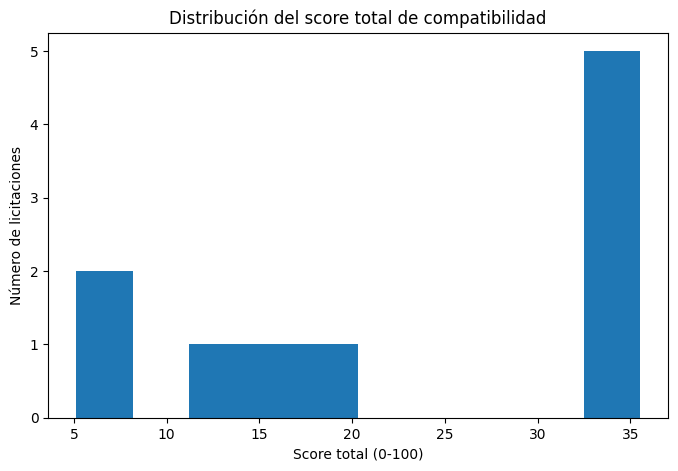

Interpretación:
- Si todos los valores quedan muy concentrados, el scoring discrimina poco.
- Si hay dispersión, el scoring está separando licitaciones con diferente compatibilidad relativa.


In [21]:
# ===============================
# 13. Gráfica 1: distribución del score total
# ===============================

valid_scores = score_df["score_total_0_100"].dropna()

if valid_scores.empty:
    print("No hay scores totales válidos para graficar.")
else:
    plt.figure(figsize=(8, 5))
    plt.hist(valid_scores, bins=min(10, max(3, len(valid_scores))))
    plt.title("Distribución del score total de compatibilidad")
    plt.xlabel("Score total (0-100)")
    plt.ylabel("Número de licitaciones")
    plt.show()

    print("Interpretación:")
    print("- Si todos los valores quedan muy concentrados, el scoring discrimina poco.")
    print("- Si hay dispersión, el scoring está separando licitaciones con diferente compatibilidad relativa.")

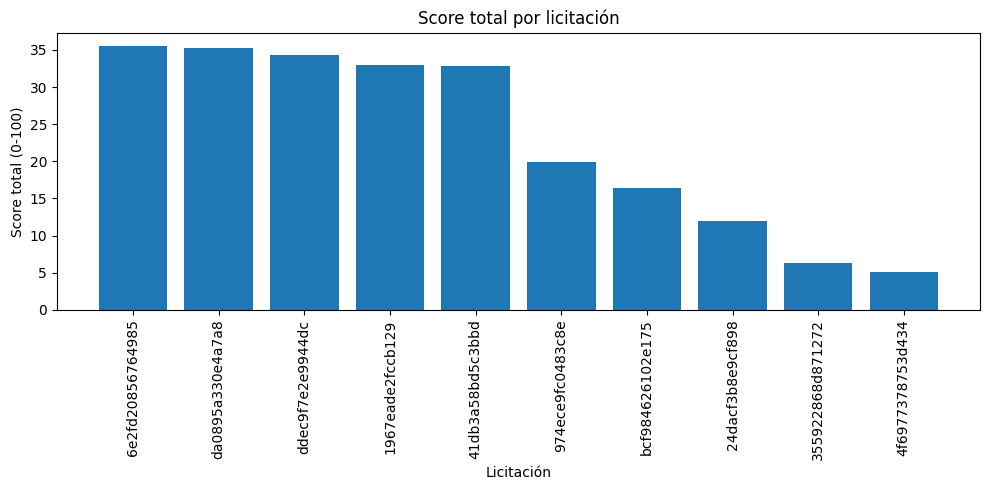

Interpretación:
- Las barras más altas representan licitaciones más parecidas al histórico de Los Tilos.
- No implica decisión automática; sirve para priorizar revisión manual.


In [22]:
# ===============================
# 14. Gráfica 2: score total por licitación
# ===============================

if valid_scores.empty:
    print("No hay scores totales válidos para graficar.")
else:
    plot_df = df_scoring_revision.copy()

    if cols_muestra.get("id") is not None and cols_muestra["id"] in plot_df.columns:
        labels = plot_df[cols_muestra["id"]].astype(str)
    elif cols_muestra.get("titulo") is not None and cols_muestra["titulo"] in plot_df.columns:
        labels = plot_df[cols_muestra["titulo"]].astype(str).str.slice(0, 40)
    else:
        labels = plot_df.index.astype(str)

    plt.figure(figsize=(10, 5))
    plt.bar(labels, plot_df["score_total_0_100"])
    plt.title("Score total por licitación")
    plt.xlabel("Licitación")
    plt.ylabel("Score total (0-100)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    print("Interpretación:")
    print("- Las barras más altas representan licitaciones más parecidas al histórico de Los Tilos.")
    print("- No implica decisión automática; sirve para priorizar revisión manual.")

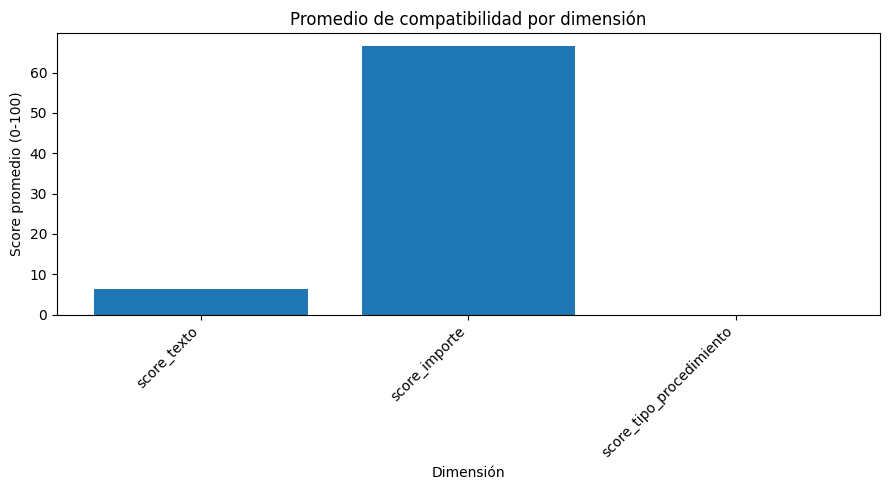

Interpretación:
- Una dimensión con promedio alto indica similitud frecuente frente al índice histórico.
- Una dimensión con promedio bajo puede indicar baja compatibilidad o poca experiencia histórica en ese aspecto.


In [23]:
# ===============================
# 15. Gráfica 3: promedio por dimensión
# ===============================

mean_scores = score_df[score_columns].mean(skipna=True).dropna()

if mean_scores.empty:
    print("No hay scores por dimensión válidos para graficar.")
else:
    plt.figure(figsize=(9, 5))
    plt.bar(mean_scores.index, mean_scores.values * 100)
    plt.title("Promedio de compatibilidad por dimensión")
    plt.xlabel("Dimensión")
    plt.ylabel("Score promedio (0-100)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print("Interpretación:")
    print("- Una dimensión con promedio alto indica similitud frecuente frente al índice histórico.")
    print("- Una dimensión con promedio bajo puede indicar baja compatibilidad o poca experiencia histórica en ese aspecto.")

## 10. Revisión de casos extremos

Se revisan las licitaciones con mayor y menor score. Esto es necesario para validar si la fórmula está comportándose de forma razonable.

In [24]:
# ===============================
# 16. Top y bottom para revisión manual
# ===============================

print("Top 5 licitaciones con mayor compatibilidad:")
display(df_scoring_revision.head(5))

print("Top 5 licitaciones con menor compatibilidad:")
display(df_scoring_revision.tail(5))

Top 5 licitaciones con mayor compatibilidad:


,licitacion_id,titulo,cpv_codes,importe_sin_impuestos,tipo_contrato,procedimiento_codigo,lugar_ejecucion,organo_contratacion,score_cpv,score_texto,score_importe,score_tipo_procedimiento,score_region,score_organo,score_total_0_100,nivel_compatibilidad
0,6e2fd20856764985,P.A.S.A. 43/2024. Servicio para la realización de pruebas de diagnóstico oftalmológico basado en inteligencia artificial para el Hospital Universi...,85121281,59992.0,Servicios,999,None,Hospital Universitario La Paz,NaN,0.110456,1.0,0.0,NaN,NaN,35.522785,Baja
1,da0895a330e4a7a8,Servicio realización RM para Laboratorio de Imagen Médica (FIBHGM PA 10/2024),85100000;85140000,102000.0,Servicios,1,None,Fundación para la Investigación Biomédica del Hospital Gregorio Marañón,NaN,0.105956,1.0,0.0,NaN,NaN,35.297816,Baja
2,ddec9f7e2e9944dc,Servicio de reconocimientos médicos personal adscrito al INSS,85121100;85121210;85121240;85121292,15975.0,Servicios,None,Segovia,,NaN,0.086609,1.0,0.0,NaN,NaN,34.330451,Baja
3,1967eade2fccb129,Contratación del servicio de Asistencia Sanitaria Especializada en Castilla y León y Cantabria para FREMAP,85100000,270639.6,Servicios,None,España - España - ESPAÑA,,NaN,0.060506,1.0,0.0,NaN,NaN,33.025297,Baja
4,41db3a58bd5c3bbd,Servicio Especializado de Rehabilitación Hospitalaria en el ámbito territorial de Mérida (Badajoz) y área de influencia,85100000,36530.0,Servicios,1,España - Badajoz - Mérida,"Dirección General de la Mutual Midat Cyclops, Mutua Colaboradora con la Seguridad Social, nº 1",NaN,0.057796,1.0,0.0,NaN,NaN,32.889801,Baja


Top 5 licitaciones con menor compatibilidad:


,licitacion_id,titulo,cpv_codes,importe_sin_impuestos,tipo_contrato,procedimiento_codigo,lugar_ejecucion,organo_contratacion,score_cpv,score_texto,score_importe,score_tipo_procedimiento,score_region,score_organo,score_total_0_100,nivel_compatibilidad
5,974ece9fc0483c8e,"Servicio de realización de pruebas de laboratorio externo para el Servicio de Bioquímica – Análisis Clínicos, con destino al Hospital Universitari...",85145000,86345.25,Servicios,1,None,Hospital Universitario Puerta de Hierro Majadahonda,NaN,0.102585,0.493576,0.0,NaN,NaN,19.936527,Baja
6,bcf984626102e175,"Servicio de prevención ajeno en las especialidades de seguridad en el trabajo, higiene industrial, ergonomía, psicosociología aplicada y medicina ...",85147000,87275.75,Servicios,1,España - Madrid,Pleno del Ayuntamiento de Villaviciosa de Odón,NaN,0.032558,0.492178,0.0,NaN,NaN,16.393233,Baja
7,24dacf3b8e9cf898,"Adquisición de diversos artículos, actuaciones y otros gastos derivados de la situación de emergencia ocasionada por la pandemia del COVID-19",85100000,126.07,Obras,999,None,Consellería de Sanidade - SERGAS,NaN,0.023597,0.359832,0.0,NaN,NaN,11.974817,Baja
8,355922868d871272,003730 - mrsa screen agar - placa,85100000,84.7,Obras,999,None,Consellería de Sanidade - SERGAS,NaN,0.019970,0.176125,0.0,NaN,NaN,6.282221,Baja
9,4f6977378753d434,"Adquisición de diversos artículos, actuaciones y otros gastos derivados de la situación de emergencia ocasionada por la pandemia del COVID-19",85100000,28.0,Obras,999,None,Consellería de Sanidade - SERGAS,NaN,0.023660,0.131478,0.0,NaN,NaN,5.127344,Baja


## 11. Diagnóstico de pesos efectivos

Como los pesos se renormalizan cuando faltan dimensiones, conviene revisar cuántas dimensiones reales entraron en cada licitación.

In [ ]:
# ===============================
# 17. Diagnóstico de dimensiones disponibles por fila
# ===============================

score_df["n_dimensiones_disponibles"] = score_df[score_columns].notna().sum(axis=1)

print("Número de dimensiones disponibles por licitación:")
print(score_df["n_dimensiones_disponibles"].value_counts().sort_index())

print("Revisión de score vs dimensiones disponibles:")
display(
    score_df[["score_total_0_100", "nivel_compatibilidad", "n_dimensiones_disponibles"]]
    .sort_values("score_total_0_100", ascending=False)
)

Número de dimensiones disponibles por licitación:
n_dimensiones_disponibles
3    10
Name: count, dtype: int64
Revisión de score vs dimensiones disponibles:


,score_total_0_100,nivel_compatibilidad,n_dimensiones_disponibles
4,35.522785,Baja,3
5,35.297816,Baja,3
9,34.330451,Baja,3
8,33.025297,Baja,3
7,32.889801,Baja,3
3,19.936527,Baja,3
6,16.393233,Baja,3
2,11.974817,Baja,3
0,6.282221,Baja,3
1,5.127344,Baja,3


: 

## 12. Conclusión operativa del notebook

Este notebook deja listo un scoring base auditable.

La decisión posterior debería ser revisar si:

1. Las columnas detectadas son las correctas.
2. El índice de Los Tilos realmente representa experiencia histórica útil.
3. El score separa razonablemente licitaciones con alta, media y baja compatibilidad.
4. Los pesos deben calibrarse según criterio experto o resultados históricos.

En una segunda versión se puede agregar:

- Validación contra licitaciones donde Los Tilos sí aplicó o ganó.
- Embeddings semánticos para texto largo.
- Extracción de información desde PDFs/documentos adjuntos.
- Un modelo supervisado si se construye una variable objetivo confiable.